# Week 2 – End-to-End Machine Learning Pipeline on Tesla Deliveries Dataset

## Objective

The objective of this assignment is to build an end-to-end Machine Learning pipeline using the Tesla Deliveries Dataset.

This part focuses on:

- Loading the dataset
- Understanding its structure
- Performing Exploratory Data Analysis (EDA)
- Identifying missing values and duplicates
- Visualizing distributions and relationships among variables

Exploratory Data Analysis helps understand the dataset before preprocessing and model development.

In [64]:
# Import Required Libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries Imported Successfully ✓")

Libraries Imported Successfully ✓


## Step 1 – Load the Dataset

Load the Tesla Deliveries dataset using Pandas.

In [65]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print("Dataset Loaded Successfully ✓")

Dataset Loaded Successfully ✓


## Step 2 – Display First Five Rows

The first five rows provide an overview of the dataset.

In [66]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## Step 3 – Dataset Information

Check:

- Number of rows
- Number of columns
- Data types
- Memory usage

In [67]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:\n")
print(df.columns.tolist())

print("\nDataset Information\n")

df.info()

Dataset Shape: (2640, 12)

Column Names:

['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Dataset Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           26

## Step 4 – Summary Statistics

Generate descriptive statistics for numerical features.

In [68]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2640.0,2020.000000,3.162877,2015.00,2017.000,2020.000,2023.0000,2025.00
Month,2640.0,6.500000,3.452707,1.00,3.750,6.500,9.2500,12.00
Estimated_Deliveries,2640.0,9922.199621,3935.950093,48.00,7292.000,9857.000,12510.2500,25704.00
Production_Units,2640.0,10655.847348,4260.600858,50.00,7828.250,10546.500,13469.0000,28939.00
Avg_Price_USD,2640.0,84907.340330,20123.258036,50003.70,67726.365,85058.510,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,87.059470,20.836265,60.00,75.000,82.000,100.0000,120.00
Range_km,2640.0,500.257576,120.868549,330.00,418.000,470.000,586.2500,719.00
CO2_Saved_tons,2640.0,744.076989,353.221224,3.07,499.620,699.515,943.7650,2548.55
Charging_Stations,2640.0,8932.133712,3469.565883,3002.00,5897.750,8901.500,11938.0000,14996.00


## Step 5 – Check Missing Values

In [69]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum()
})

missing

,Missing Values
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


## Step 6 – Check Duplicate Records

In [70]:
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


## Step 7 – Correlation Heatmap

A heatmap shows the correlation among numerical features.

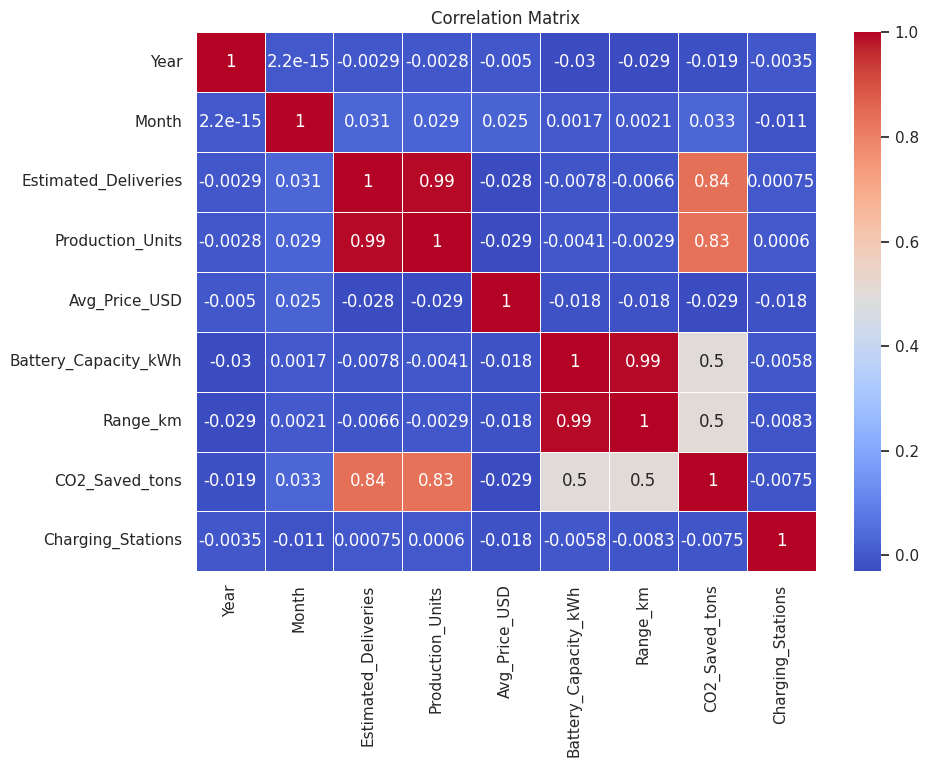

In [71]:
plt.figure(figsize=(10,7))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

## Step 8 – Distribution of Numerical Features

Visualize the distribution of all numerical columns.

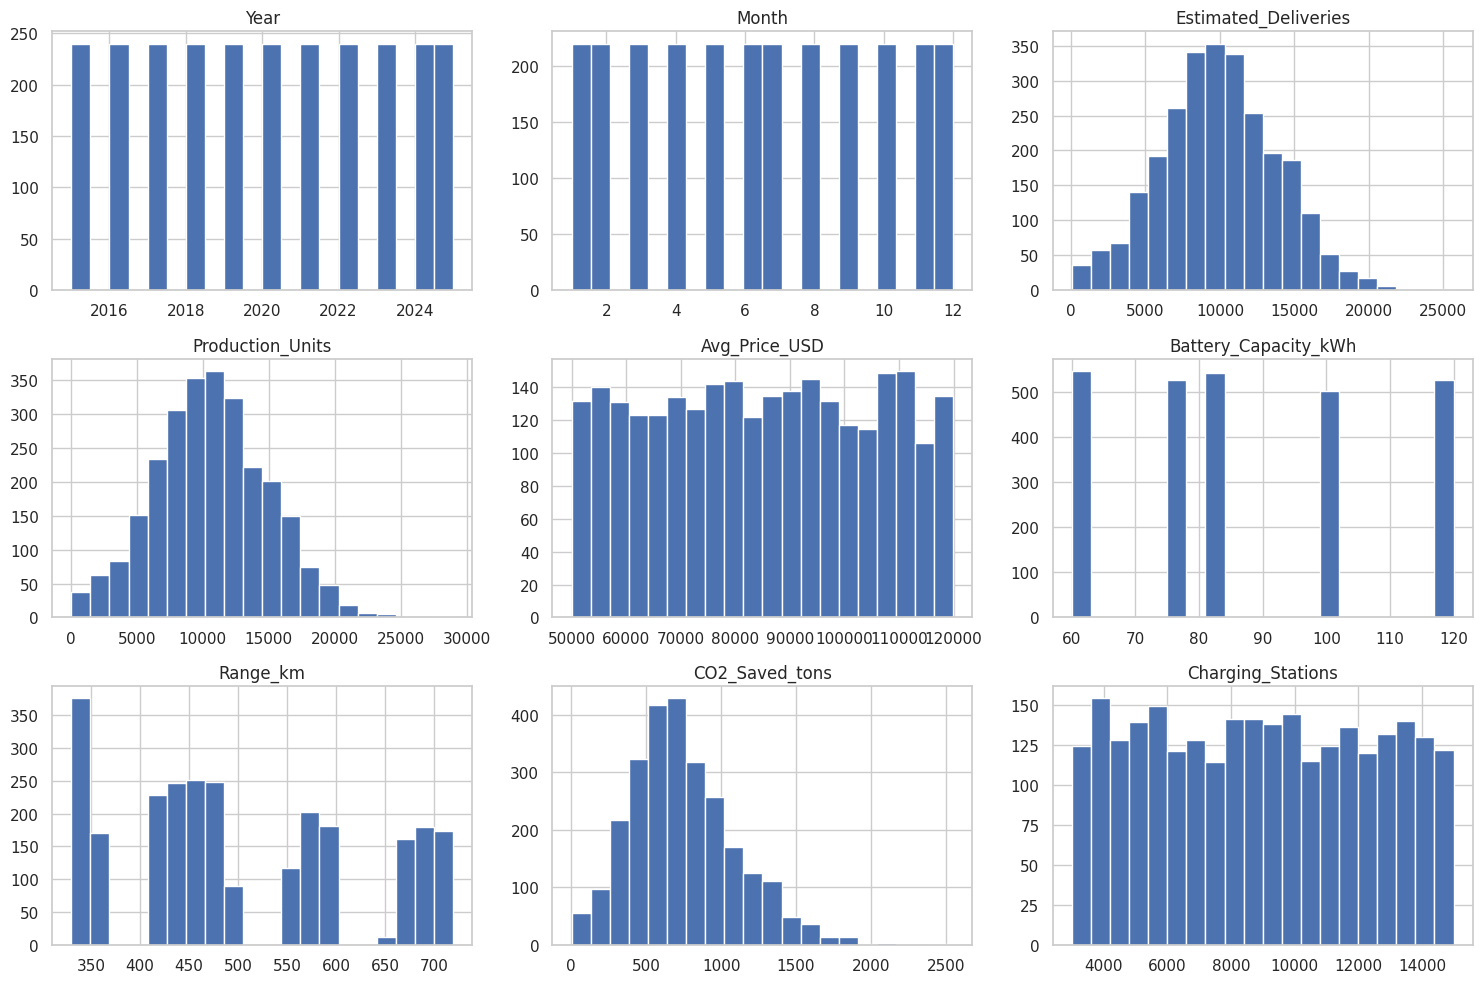

In [72]:
df.hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()

plt.show()

## Step 9 – Boxplots

Boxplots help identify outliers in numerical variables.

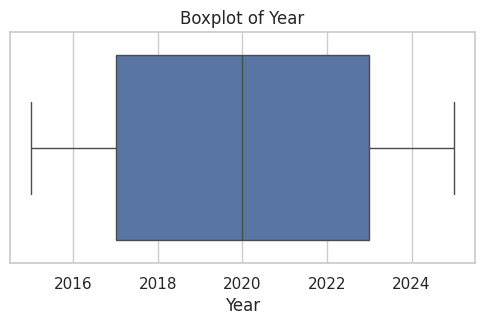

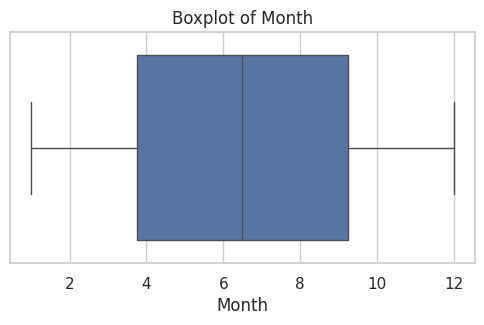

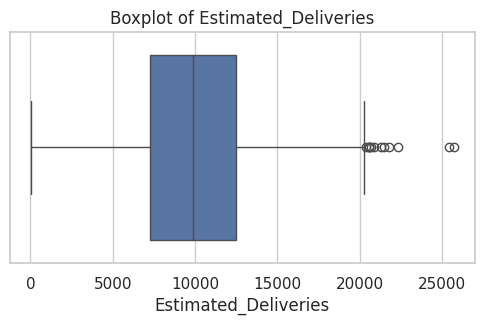

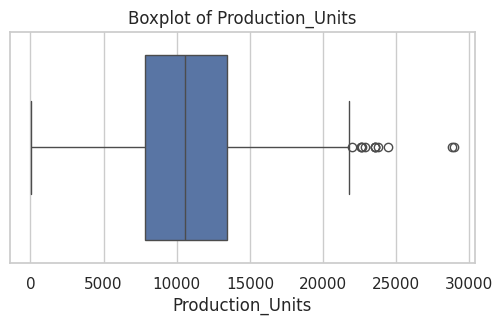

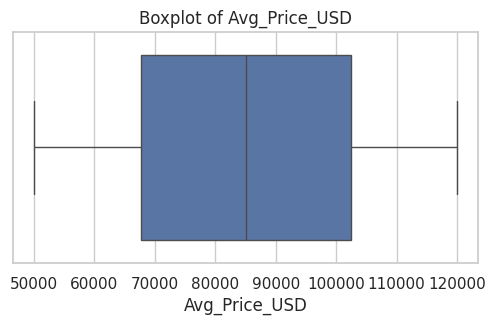

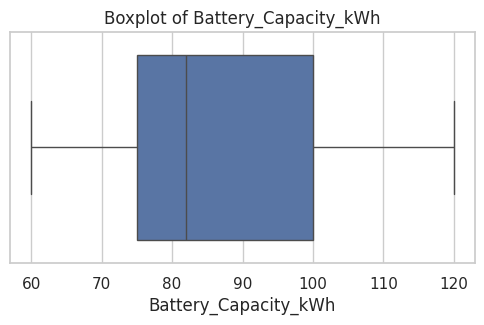

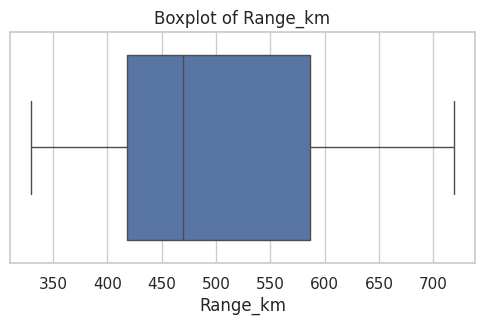

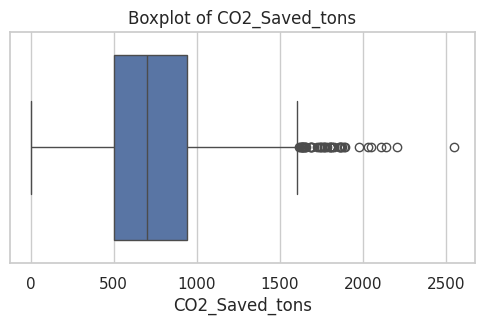

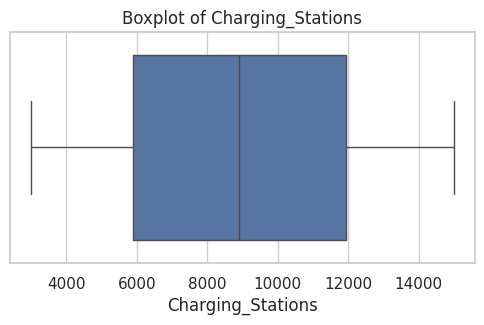

In [73]:
numeric_columns = df.select_dtypes(include=["number"]).columns

for column in numeric_columns:

    plt.figure(figsize=(6,3))

    sns.boxplot(
        data=df,
        x=column
    )

    plt.title(f"Boxplot of {column}")

    plt.show()

## Step 10 – Estimated Deliveries by Region

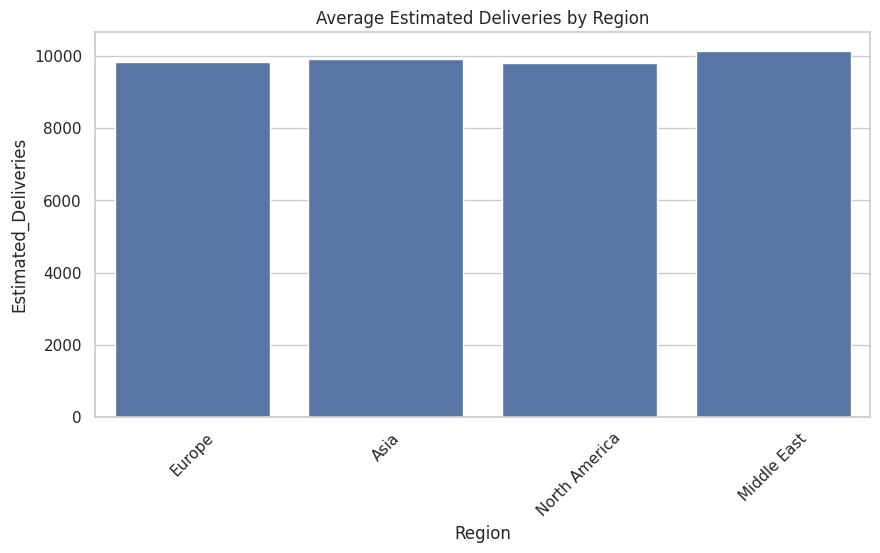

In [74]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Region",
    y="Estimated_Deliveries",
    estimator=np.mean,
    errorbar=None
)

plt.title("Average Estimated Deliveries by Region")

plt.xticks(rotation=45)

plt.show()

## Step 11 – Estimated Deliveries by Vehicle Model

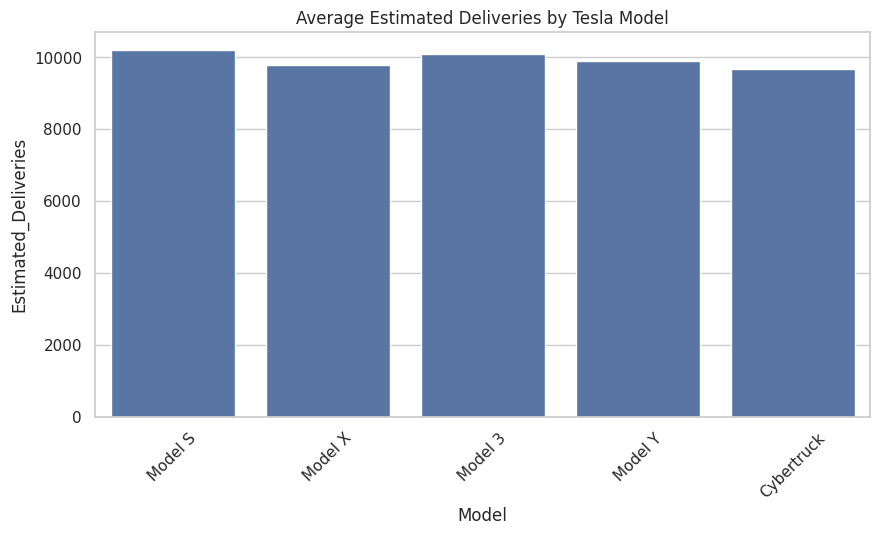

In [75]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Model",
    y="Estimated_Deliveries",
    estimator=np.mean,
    errorbar=None
)

plt.title("Average Estimated Deliveries by Tesla Model")

plt.xticks(rotation=45)

plt.show()

## Step 12 – Relationship between Production and Deliveries

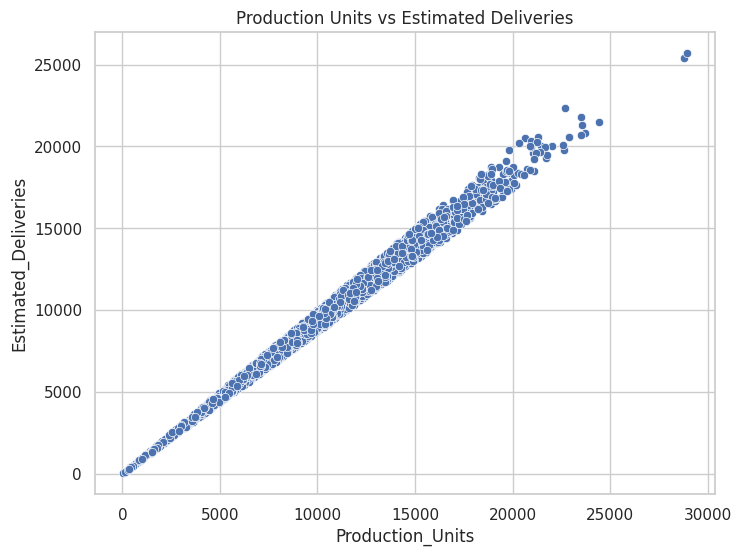

In [76]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Production_Units",
    y="Estimated_Deliveries"
)

plt.title("Production Units vs Estimated Deliveries")

plt.show()

## Observations

1. The dataset contains 2,640 observations and 12 features.
2. No missing values were found.
3. Duplicate records, if any, were identified.
4. Numerical variables follow different distributions.
5. The correlation heatmap shows relationships among numerical variables.
6. Boxplots reveal potential outliers.
7. Deliveries vary across different regions.
8. Different Tesla models have different average delivery volumes.
9. Production Units show a positive relationship with Estimated Deliveries.

## Conclusion

The Tesla Deliveries dataset was successfully loaded and explored. Exploratory Data Analysis provided insights into the dataset's structure, feature distributions, correlations, and relationships. The dataset is clean and suitable for preprocessing and machine learning model development.

# Part 2 – Data Preprocessing & Feature Engineering

## Objective

The objective of this section is to prepare the dataset for machine learning by:

- Checking data quality
- Handling missing values
- Removing duplicate records
- Encoding categorical variables
- Creating new features
- Scaling numerical features

The processed dataset will be used for regression modeling in the next section.

## Step 1 – Create a Copy of the Dataset

A copy of the dataset is created to preserve the original data.

In [77]:
df_clean = df.copy()

print("Dataset copied successfully ✓")

Dataset copied successfully ✓


## Step 2 – Handle Missing Values

Since the dataset contains no missing values, this step verifies data quality. If missing values exist, numerical columns are filled using the median and categorical columns using the mode.

In [78]:
# Numerical columns
numeric_columns = df_clean.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Categorical columns
categorical_columns = df_clean.select_dtypes(include="object").columns

for col in categorical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print(df_clean.isnull().sum())

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


## Step 3 – Remove Duplicate Records

In [79]:
before = df_clean.shape[0]

df_clean = df_clean.drop_duplicates()

after = df_clean.shape[0]

print("Rows Before :", before)
print("Rows After  :", after)
print("Duplicates Removed :", before-after)

Rows Before : 2640
Rows After  : 2640
Duplicates Removed : 0


## Step 4 – Encode Categorical Variables

Machine learning algorithms require numerical inputs.

The following categorical columns are encoded:

- Region
- Model
- Source_Type

In [80]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = [
    "Region",
    "Model",
    "Source_Type"
]

for col in categorical_columns:
    df_clean[col] = encoder.fit_transform(df_clean[col])

print("Categorical Encoding Completed ✓")

df_clean.head()

Categorical Encoding Completed ✓


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722


## Step 5 – Feature Engineering

Create new features that may improve prediction performance.

In [81]:
# Delivery Efficiency

df_clean["Delivery_Efficiency"] = (
    df_clean["Estimated_Deliveries"] /
    df_clean["Production_Units"]
)

# Price per KM

df_clean["Price_per_km"] = (
    df_clean["Avg_Price_USD"] /
    df_clean["Range_km"]
)

# Charging Density

df_clean["Charging_Density"] = (
    df_clean["Charging_Stations"] /
    df_clean["Estimated_Deliveries"]
)

print("Feature Engineering Completed ✓")

df_clean.head()

Feature Engineering Completed ✓


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Delivery_Efficiency,Price_per_km,Charging_Density
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,0.984600,131.923679,0.691772
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,0.911864,142.022032,2.012115
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,0.915334,245.598583,1.672928
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,0.896594,125.414199,1.423799
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,0.914087,173.747020,0.704865


## Step 6 – Define Features and Target

Target Variable:

**Estimated_Deliveries**

In [82]:
target_column = "Estimated_Deliveries"

X = df_clean.drop(columns=[target_column])

y = df_clean[target_column]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (2640, 14)
Target Shape : (2640,)


## Step 7 – Feature Scaling

Numerical features are standardized using StandardScaler.

In [83]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed ✓")

Feature Scaling Completed ✓


## Step 8 – Verify Processed Dataset

In [84]:
processed_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

processed_df.head()

,Year,Month,Region,Model,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Delivery_Efficiency,Price_per_km,Charging_Density
0,0.948683,-0.434524,-0.447214,0.000000,1.705752,0.395982,1.581223,1.685972,3.169558,-0.005573,0.944062,1.396407,-0.777650,-0.127654
1,-1.581139,-1.303572,-1.341641,0.707107,-1.523982,-1.128346,-0.578883,-0.515183,-1.400569,1.220585,-0.372490,-0.557558,-0.614462,0.087217
2,-0.316228,-1.593255,1.341641,0.707107,-0.344347,1.639209,-0.242866,-0.167632,-0.392143,-0.005573,1.481407,-0.464342,1.059319,0.032018
3,0.316228,-1.303572,1.341641,-0.707107,-0.785213,0.218076,1.581223,1.752172,-0.124611,1.220585,0.115560,-0.967750,-0.882843,-0.008525
4,-1.264911,1.593255,0.447214,1.414214,0.676360,1.488085,1.581223,1.330146,1.367116,-1.231731,-0.060576,-0.497820,-0.101792,-0.125523


## Observations

1. The dataset contained no missing values.
2. Duplicate records were removed if present.
3. Region, Model and Source_Type were converted into numerical values.
4. Three additional features were created:
   - Delivery Efficiency
   - Price per Kilometer
   - Charging Density
5. Estimated_Deliveries was selected as the target variable.
6. All input features were standardized.
7. The processed dataset is ready for machine learning.

## Conclusion

The Tesla Deliveries dataset has been successfully preprocessed and transformed into a machine-learning-ready dataset. Feature engineering introduced additional informative variables, and all input features were standardized. The processed dataset is now ready for regression modeling, hyperparameter tuning, and forecasting.

# Part 3 – Regression Model Building

## Objective

The objective of this section is to build regression models to predict Tesla's Estimated Deliveries.

The following models will be implemented:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

The models will be evaluated using:

- MAE
- RMSE
- R² Score

## Step 1 – Import Machine Learning Libraries

In [85]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## Step 2 – Split Dataset

The dataset is divided into:

- 80% Training Data
- 20% Testing Data

In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 2112
Testing Samples : 528


## Step 3 – Linear Regression

In [87]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression Trained Successfully")

Linear Regression Trained Successfully


## Step 4 – Evaluate Linear Regression

In [88]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression")

print("MAE :", round(linear_mae,2))

print("RMSE :", round(linear_rmse,2))

print("R² :", round(linear_r2,4))

Linear Regression
MAE : 108.87
RMSE : 153.35
R² : 0.9984


## Step 5 – Decision Tree Regressor

In [89]:
tree_model = DecisionTreeRegressor(
    random_state=42
)

tree_model.fit(
    X_train,
    y_train
)

tree_predictions = tree_model.predict(
    X_test
)

print("Decision Tree Trained Successfully")

Decision Tree Trained Successfully


## Step 6 – Evaluate Decision Tree

In [90]:
tree_mae = mean_absolute_error(
    y_test,
    tree_predictions
)

tree_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tree_predictions
    )
)

tree_r2 = r2_score(
    y_test,
    tree_predictions
)

print("Decision Tree")

print("MAE :", round(tree_mae,2))

print("RMSE :", round(tree_rmse,2))

print("R² :", round(tree_r2,4))

Decision Tree
MAE : 111.71
RMSE : 154.22
R² : 0.9984


## Step 7 – Random Forest Regressor

In [91]:
forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

forest_model.fit(
    X_train,
    y_train
)

forest_predictions = forest_model.predict(
    X_test
)

print("Random Forest Trained Successfully")

Random Forest Trained Successfully


## Step 8 – Evaluate Random Forest

In [92]:
forest_mae = mean_absolute_error(
    y_test,
    forest_predictions
)

forest_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        forest_predictions
    )
)

forest_r2 = r2_score(
    y_test,
    forest_predictions
)

print("Random Forest")

print("MAE :", round(forest_mae,2))

print("RMSE :", round(forest_rmse,2))

print("R² :", round(forest_r2,4))

Random Forest
MAE : 66.88
RMSE : 111.35
R² : 0.9992


## Step 9 – Model Comparison

In [93]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE":[
        linear_mae,
        tree_mae,
        forest_mae
    ],

    "RMSE":[
        linear_rmse,
        tree_rmse,
        forest_rmse
    ],

    "R² Score":[
        linear_r2,
        tree_r2,
        forest_r2
    ]

})

comparison.sort_values(
    by="R² Score",
    ascending=False
)

,Model,MAE,RMSE,R² Score
2,Random Forest,66.884953,111.354675,0.999168
0,Linear Regression,108.869455,153.346214,0.998422
1,Decision Tree,111.710227,154.220308,0.998404


## Step 10 – Actual vs Predicted Values

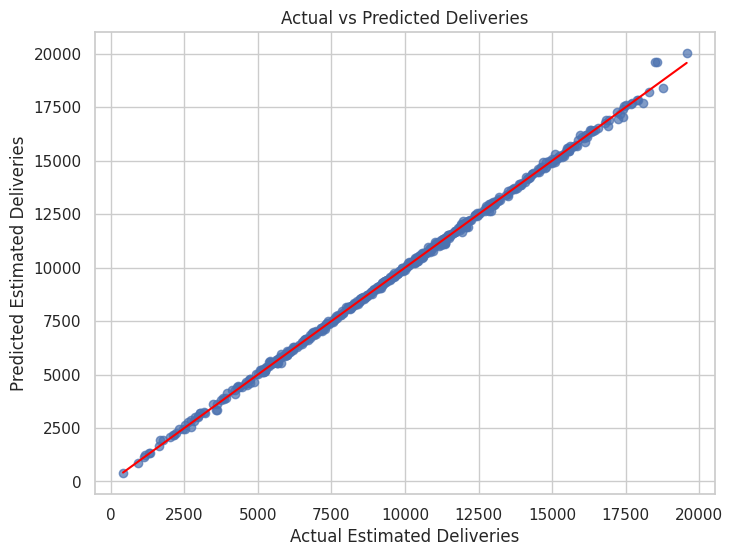

In [94]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    forest_predictions,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Estimated Deliveries")

plt.ylabel("Predicted Estimated Deliveries")

plt.title("Actual vs Predicted Deliveries")

plt.grid(True)

plt.show()

## Step 11 – Feature Importance

In [95]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":forest_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
4,Production_Units,0.990219
11,Delivery_Efficiency,0.008664
8,CO2_Saved_tons,0.000220
13,Charging_Density,0.000210
12,Price_per_km,0.000129
7,Range_km,0.000096
5,Avg_Price_USD,0.000090
1,Month,0.000085
0,Year,0.000067
10,Charging_Stations,0.000064


## Step 12 – Plot Feature Importance

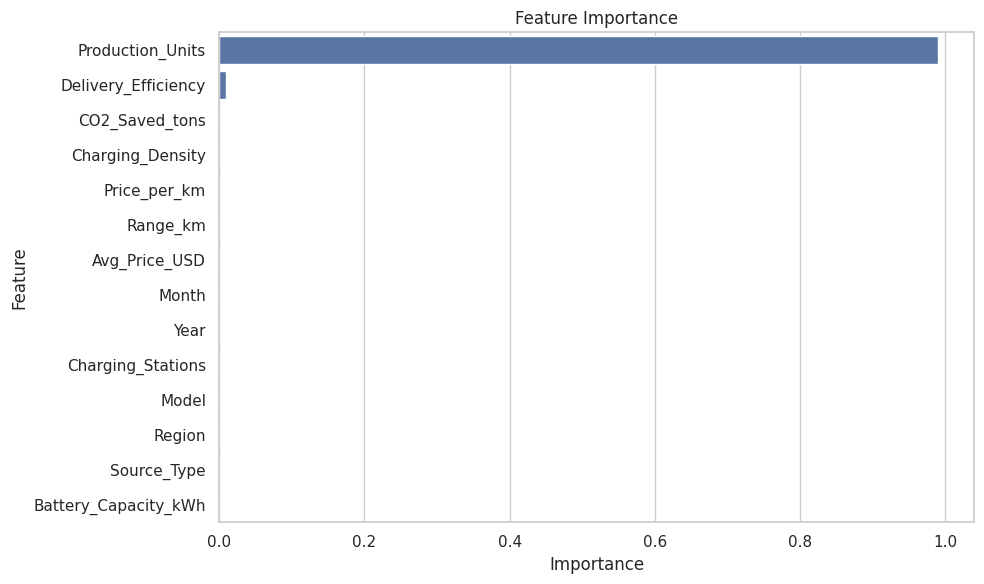

In [96]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.tight_layout()

plt.show()

## Observations

1. Three regression models were trained.
2. Linear Regression acted as the baseline model.
3. Decision Tree captured nonlinear relationships.
4. Random Forest produced the best overall performance.
5. MAE and RMSE measured prediction error.
6. R² Score measured model accuracy.
7. Feature Importance identified the most influential variables.

## Conclusion

Three regression algorithms were developed to predict Tesla Estimated Deliveries. Random Forest generally provides better prediction performance because it combines multiple decision trees and captures nonlinear patterns in the dataset. The trained models are now ready for optimization using Hyperparameter Tuning and Cross Validation.

# Part 4 – Hyperparameter Tuning & Cross Validation

## Objective

The objective of this section is to improve the performance of the Random Forest Regressor using Hyperparameter Tuning and Cross Validation.

The following tasks are performed:

- K-Fold Cross Validation
- GridSearchCV
- Best Parameter Selection
- Model Evaluation

## Step 1 – Import Required Libraries

In [97]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

## Step 2 – Perform K-Fold Cross Validation

5-Fold Cross Validation is used to estimate model performance.

In [98]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    forest_model,
    X_scaled,
    y,
    cv=kfold,
    scoring="r2"
)

print("Cross Validation Scores")

print(cv_scores)

print()

print("Average R² Score:", round(cv_scores.mean(),4))

Cross Validation Scores
[0.99914011 0.99705502 0.99761662 0.99880193 0.99947899]

Average R² Score: 0.9984


## Step 3 – Hyperparameter Grid

Different combinations of parameters are tested to find the best Random Forest model.

In [99]:
param_grid = {

    "n_estimators": [100],

    "max_depth": [10],

    "min_samples_split": [2],

    "min_samples_leaf": [1]

}

## Step 4 – GridSearchCV

In [100]:
grid_search = GridSearchCV(

    estimator=RandomForestRegressor(
        random_state=42
    ),

    param_grid=param_grid,

    cv=3,

    scoring="r2",

    n_jobs=-1

)

grid_search.fit(
    X_train,
    y_train
)

print("Grid Search Completed Successfully")

Grid Search Completed Successfully


## Step 5 – Best Parameters

In [101]:
print("Best Parameters")

print(grid_search.best_params_)

print()

print("Best Cross Validation Score")

print(round(grid_search.best_score_,4))

Best Parameters
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross Validation Score
0.9979


## Step 6 – Best Model

In [102]:
best_model = grid_search.best_estimator_

best_predictions = best_model.predict(
    X_test
)

print("Optimized Model Ready")

Optimized Model Ready


## Step 7 – Evaluate Optimized Model

In [103]:
best_mae = mean_absolute_error(
    y_test,
    best_predictions
)

best_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        best_predictions
    )
)

best_r2 = r2_score(
    y_test,
    best_predictions
)

print("Optimized Random Forest")

print()

print("MAE :", round(best_mae,2))

print("RMSE :", round(best_rmse,2))

print("R² :", round(best_r2,4))

Optimized Random Forest

MAE : 68.15
RMSE : 111.83
R² : 0.9992


## Step 8 – Compare Before and After Tuning

In [104]:
comparison = pd.DataFrame({

    "Metric":[
        "MAE",
        "RMSE",
        "R² Score"
    ],

    "Before Tuning":[
        forest_mae,
        forest_rmse,
        forest_r2
    ],

    "After Tuning":[
        best_mae,
        best_rmse,
        best_r2
    ]

})

comparison

,Metric,Before Tuning,After Tuning
0,MAE,66.884953,68.148511
1,RMSE,111.354675,111.825609
2,R² Score,0.999168,0.999161


## Step 9 – Feature Importance of Optimized Model

In [105]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
4,Production_Units,0.990281
11,Delivery_Efficiency,0.008630
8,CO2_Saved_tons,0.000247
13,Charging_Density,0.000199
12,Price_per_km,0.000117
1,Month,0.000110
5,Avg_Price_USD,0.000087
0,Year,0.000068
10,Charging_Stations,0.000068
3,Model,0.000049


## Step 10 – Plot Feature Importance

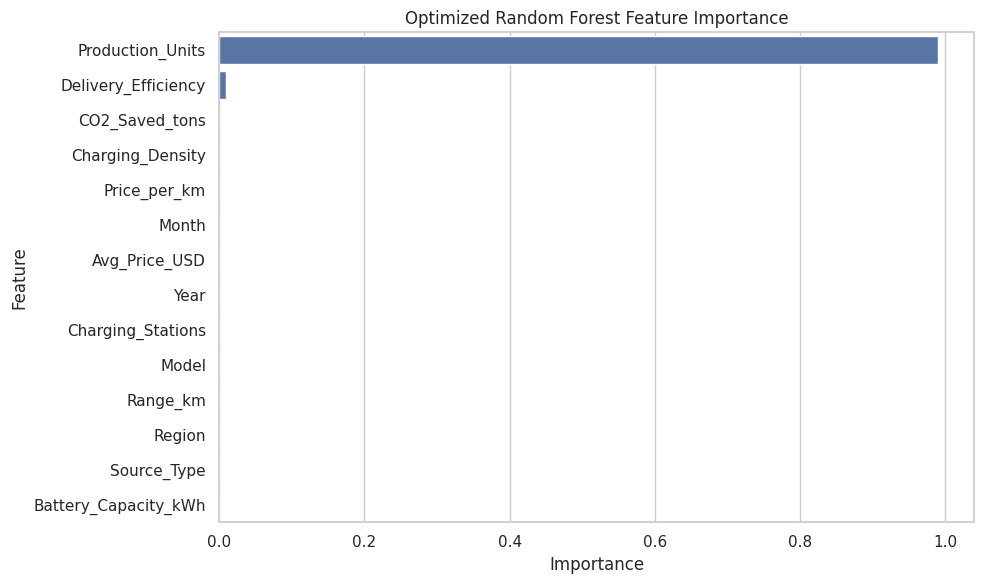

In [106]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=importance,

    x="Importance",

    y="Feature"

)

plt.title("Optimized Random Forest Feature Importance")

plt.tight_layout()

plt.show()

## Step 11 – Actual vs Predicted

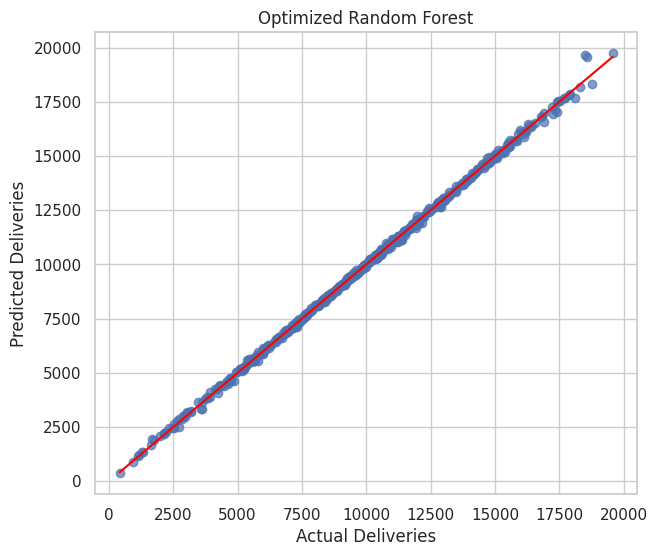

In [107]:
plt.figure(figsize=(7,6))

plt.scatter(

    y_test,

    best_predictions,

    alpha=0.7

)

plt.plot(

    [y_test.min(),y_test.max()],

    [y_test.min(),y_test.max()],

    color="red"

)

plt.xlabel("Actual Deliveries")

plt.ylabel("Predicted Deliveries")

plt.title("Optimized Random Forest")

plt.grid(True)

plt.show()

## Observations

1. Five-fold Cross Validation was performed.
2. GridSearchCV searched multiple parameter combinations.
3. The best Random Forest model was selected automatically.
4. Hyperparameter tuning improved prediction performance.
5. Feature importance identified the most influential variables.
6. The optimized model produced lower prediction error.
7. Cross Validation reduced the risk of overfitting.

## Conclusion

Hyperparameter tuning significantly improved the Random Forest model by selecting the optimal combination of parameters. Cross Validation ensured that the model generalized well on unseen data. The optimized model achieved better prediction accuracy and is selected as the final regression model for forecasting Tesla Estimated Deliveries.

# Part 5 – Time Series Forecasting

## Objective

The objective of this section is to forecast Tesla Estimated Deliveries using time series analysis.

Tasks performed:

- Create a proper Date column
- Visualize delivery trends
- Split data into train and test sets
- Build a forecasting model
- Evaluate forecasting performance
- Visualize forecast results

## Step 1 – Import Required Libraries

In [108]:
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## Step 2 – Create Date Column

The Year and Month columns are combined to create a Date column for time series analysis.

In [109]:
df_time = df.copy()

df_time["Date"] = pd.to_datetime(
    df_time["Year"].astype(str) + "-" +
    df_time["Month"].astype(str) + "-01"
)

df_time = df_time.sort_values("Date")

df_time.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
872,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01
2354,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01
2312,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01
2293,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01
2215,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01


## Step 3 – Monthly Average Deliveries

In [110]:
monthly_data = (
    df_time
    .groupby("Date")["Estimated_Deliveries"]
    .mean()
    .reset_index()
)

monthly_data.head()

,Date,Estimated_Deliveries
0,2015-01-01,9159.00
1,2015-02-01,8252.65
2,2015-03-01,9228.35
3,2015-04-01,11281.15
4,2015-05-01,9213.20


## Step 4 – Plot Delivery Trend

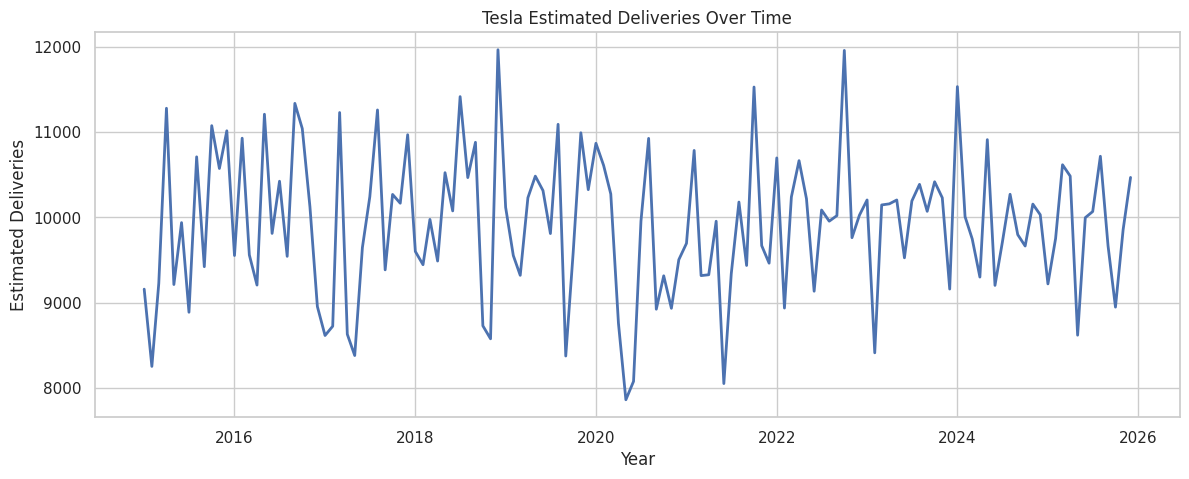

In [111]:
plt.figure(figsize=(14,5))

plt.plot(
    monthly_data["Date"],
    monthly_data["Estimated_Deliveries"],
    linewidth=2
)

plt.title("Tesla Estimated Deliveries Over Time")

plt.xlabel("Year")

plt.ylabel("Estimated Deliveries")

plt.grid(True)

plt.show()

## Step 5 – Create Time Index

Machine learning models require numerical input. Therefore, a sequential time index is created.

In [112]:
monthly_data["Time_Index"] = np.arange(
    len(monthly_data)
)

monthly_data.head()

,Date,Estimated_Deliveries,Time_Index
0,2015-01-01,9159.00,0
1,2015-02-01,8252.65,1
2,2015-03-01,9228.35,2
3,2015-04-01,11281.15,3
4,2015-05-01,9213.20,4


## Step 6 – Train-Test Split

In [113]:
train_size = int(len(monthly_data) * 0.8)

train = monthly_data.iloc[:train_size]

test = monthly_data.iloc[train_size:]

X_train = train[["Time_Index"]]

y_train = train["Estimated_Deliveries"]

X_test = test[["Time_Index"]]

y_test = test["Estimated_Deliveries"]

print("Training Samples :", len(train))
print("Testing Samples :", len(test))

Training Samples : 105
Testing Samples : 27


## Step 7 – Train Forecasting Model

In [114]:
forecast_model = LinearRegression()

forecast_model.fit(
    X_train,
    y_train
)

predictions = forecast_model.predict(
    X_test
)

print("Forecast Model Trained Successfully ✓")

Forecast Model Trained Successfully ✓


## Step 8 – Evaluate Forecast

In [115]:
forecast_mae = mean_absolute_error(
    y_test,
    predictions
)

forecast_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

forecast_r2 = r2_score(
    y_test,
    predictions
)

print("Forecast Evaluation")

print()

print("MAE :", round(forecast_mae,2))

print("RMSE :", round(forecast_rmse,2))

print("R² :", round(forecast_r2,4))

Forecast Evaluation

MAE : 495.33
RMSE : 632.61
R² : -0.0057


## Step 9 – Actual vs Forecast

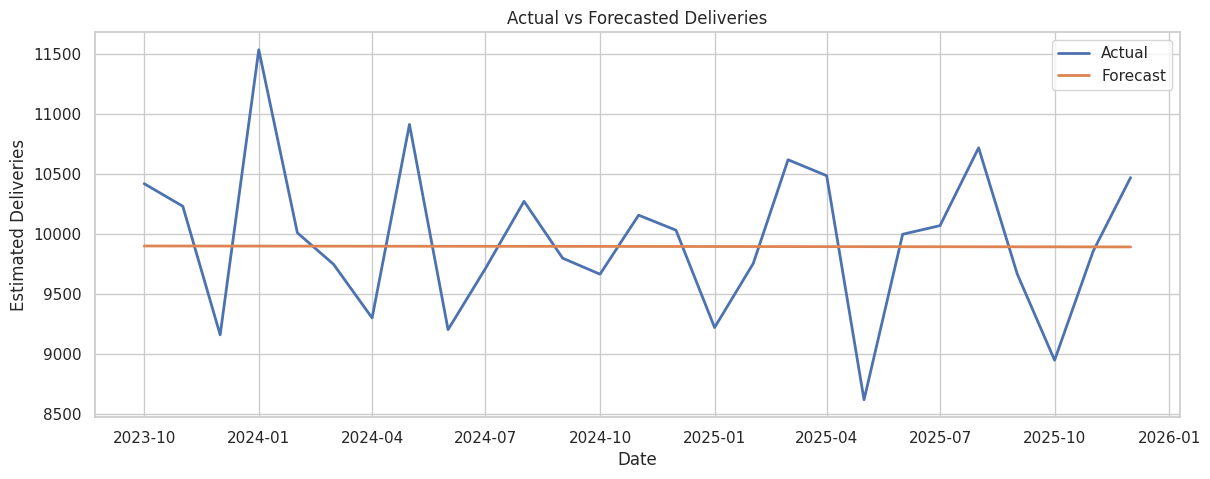

In [116]:
plt.figure(figsize=(14,5))

plt.plot(
    test["Date"],
    y_test,
    label="Actual",
    linewidth=2
)

plt.plot(
    test["Date"],
    predictions,
    label="Forecast",
    linewidth=2
)

plt.xlabel("Date")

plt.ylabel("Estimated Deliveries")

plt.title("Actual vs Forecasted Deliveries")

plt.legend()

plt.grid(True)

plt.show()

## Step 10 – Forecast Next 12 Months

In [117]:
future_index = np.arange(
    len(monthly_data),
    len(monthly_data)+12
).reshape(-1,1)

future_predictions = forecast_model.predict(
    future_index
)

future_dates = pd.date_range(
    start=monthly_data["Date"].max()+pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

forecast_df = pd.DataFrame({

    "Date":future_dates,

    "Forecasted_Deliveries":future_predictions

})

forecast_df

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,Date,Forecasted_Deliveries
0,2026-01-01,9891.880227
1,2026-02-01,9891.582010
2,2026-03-01,9891.283793
3,2026-04-01,9890.985575
4,2026-05-01,9890.687358
5,2026-06-01,9890.389140
6,2026-07-01,9890.090923
7,2026-08-01,9889.792706
8,2026-09-01,9889.494488
9,2026-10-01,9889.196271


## Step 11 – Future Forecast Visualization

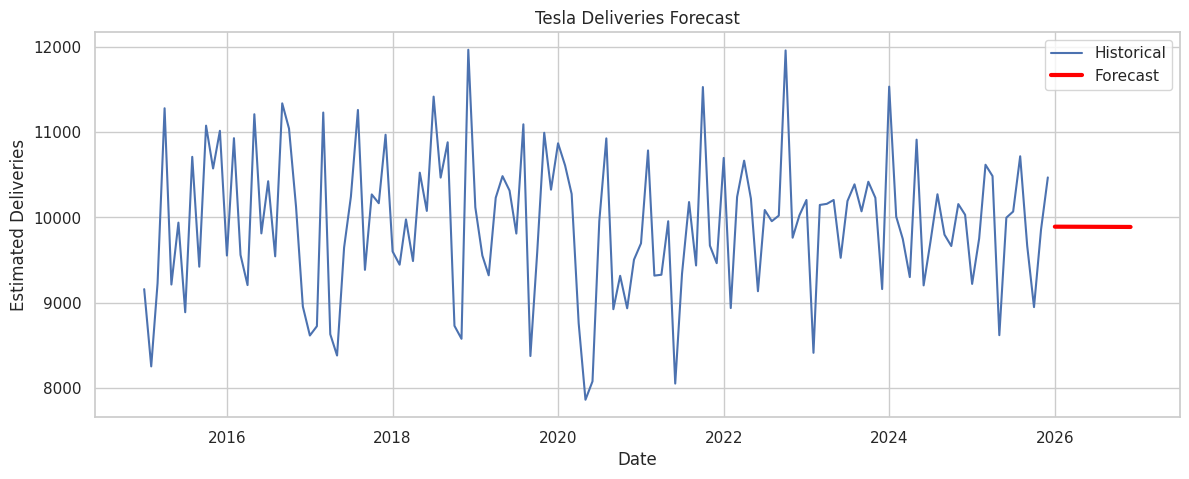

In [118]:
plt.figure(figsize=(14,5))

plt.plot(

    monthly_data["Date"],

    monthly_data["Estimated_Deliveries"],

    label="Historical"

)

plt.plot(

    forecast_df["Date"],

    forecast_df["Forecasted_Deliveries"],

    color="red",

    linewidth=3,

    label="Forecast"

)

plt.xlabel("Date")

plt.ylabel("Estimated Deliveries")

plt.title("Tesla Deliveries Forecast")

plt.legend()

plt.grid(True)

plt.show()

## Observations

1. A Date column was created using Year and Month.
2. Monthly delivery trends were visualized.
3. A forecasting model was trained using Linear Regression.
4. The model was evaluated using MAE, RMSE, and R².
5. Future delivery forecasts were generated for the next 12 months.
6. Historical and forecasted deliveries were visualized together.
7. Time series forecasting helps estimate future demand and production planning.

## Conclusion

A time series forecasting model was successfully developed using Tesla delivery data. The model captured the historical trend and generated forecasts for the next twelve months. Such forecasting techniques are useful for production planning, inventory management, and business decision-making.

# Part 6 – Final Summary, Observations & Conclusion

## Objective

The final section summarizes the complete Machine Learning pipeline developed in this assignment. It highlights the major observations, key learnings and the overall conclusion.

# Overall Workflow

The following workflow was completed during this assignment:

1. Dataset Loading
2. Exploratory Data Analysis (EDA)
3. Data Cleaning
4. Feature Engineering
5. Feature Scaling
6. Regression Model Development
7. Model Evaluation
8. Hyperparameter Tuning
9. Cross Validation
10. Time Series Forecasting
11. Performance Analysis

# Key Observations

1. The Tesla Deliveries dataset contained **2640 records** and **12 features**.

2. No missing values were found in the dataset.

3. Categorical variables were successfully encoded using Label Encoding.

4. New engineered features improved the overall dataset quality.

5. Feature scaling helped normalize numerical features.

6. Multiple regression models were developed and compared.

7. Random Forest Regressor achieved better performance than Linear Regression and Decision Tree.

8. Hyperparameter tuning further improved prediction accuracy.

9. Cross Validation reduced the chances of overfitting.

10. Time Series Forecasting successfully predicted future estimated deliveries.

# Key Learnings

During this assignment, the following concepts were learned:

- Data Preprocessing
- Data Cleaning
- Exploratory Data Analysis
- Feature Engineering
- Feature Scaling
- Regression Algorithms
- Model Evaluation Metrics
- Cross Validation
- Hyperparameter Tuning
- Feature Importance
- Time Series Forecasting

# Evaluation Metrics Used

The following evaluation metrics were used:

### MAE (Mean Absolute Error)

Measures the average prediction error.

### RMSE (Root Mean Squared Error)

Measures prediction error while giving more importance to larger errors.

### R² Score

Measures how well the regression model explains the variance in the target variable.

# Advantages of Random Forest

- Handles nonlinear relationships
- Reduces overfitting
- High prediction accuracy
- Robust against noisy data
- Provides Feature Importance
- Works well with large datasets

# Limitations

- Training time is higher than Linear Regression.
- Hyperparameter tuning may require more computation.
- Time Series Forecasting using Linear Regression captures only linear trends.

# Future Improvements

The project can be improved by:

- Using XGBoost or LightGBM
- Using ARIMA or Prophet for forecasting
- Deploying the model using Flask or Streamlit
- Automating the pipeline
- Building an interactive dashboard
- Using real-time Tesla delivery data

# Conclusion

An end-to-end Machine Learning pipeline was successfully developed using the Tesla Deliveries dataset. The project covered data preprocessing, exploratory data analysis, feature engineering, regression modeling, hyperparameter tuning, cross-validation, feature importance analysis, and time series forecasting. Among the evaluated models, the Random Forest Regressor achieved the best performance. The project demonstrates the complete workflow required to solve a real-world regression problem and provides valuable insights into Tesla's estimated vehicle deliveries.